<a href="https://colab.research.google.com/github/gabbarilirodrigues-commits/mvp-machine-learning-qav/blob/main/MVP_Vendas_de_Querose_de_Avia%C3%A7%C3%A3o_GabrielaBarili.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics  
## Previsão de vendas anuais de querosene de aviação por município
**Nome:** Gabriela Rodrigues Barili

**Matrícula:** 4052025002216

**Data:** 07/2026

**Dataset:** Vendas anuais de querosene de aviação por município — ANP (GOV.br)

**Tipo de problema:** Regressão

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste e validação temporal | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos comparados | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |

# 1. Definição do problema

## 1.1 Descrição do problema

Este MVP utiliza dados públicos da ANP sobre vendas anuais de querosene de aviação (QAV) por município no Brasil. O QAV é um insumo diretamente relacionado à atividade aérea, pois sua venda tende a acompanhar a movimentação de voos, aeroportos, rotas e demanda regional por transporte aéreo.

O problema escolhido é prever o volume anual de vendas de QAV em litros por município, utilizando informações históricas como ano, região, UF, município e vendas anteriores. Essa previsão pode apoiar análises de planejamento, acompanhamento de demanda e identificação de municípios com maior ou menor consumo esperado.

O principal interessado nessa solução poderia ser uma área de planejamento, inteligência de mercado, logística, regulação ou análise de dados do setor de combustíveis e aviação. O tema é relevante porque permite transformar uma base histórica pública em uma aplicação prática de Machine Learning para estimar volumes futuros e comparar padrões regionais.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o volume anual de vendas de querosene de aviação por município, comparando um modelo baseline com modelos candidatos de regressão e discutindo suas limitações.

## 1.3 Tipo de problema

**Tipo escolhido:** regressão com característica temporal.

**Justificativa:** o alvo do modelo é a coluna `VENDAS`, que representa um valor numérico contínuo em litros. Como os dados estão organizados por ano, a divisão entre treino e teste deve respeitar a ordem temporal, evitando que anos futuros sejam usados para treinar modelos que deveriam prever anos posteriores.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. Municípios com maior venda histórica de QAV tendem a continuar apresentando maior volume nos anos seguintes.
2. A região, a UF e o município ajudam a explicar diferenças de consumo entre localidades.
3. Variáveis defasadas, como a venda do ano anterior, podem melhorar a previsão por capturar o comportamento histórico de cada município.

**Critérios de sucesso:**

- **Métrica principal:** RMSE, pois penaliza mais erros grandes, importantes neste problema devido à existência de municípios com volumes muito altos.
- **Métricas complementares:** MAE e R².
- **Resultado mínimo esperado:** superar o baseline de mediana e obter R² positivo no conjunto de teste.
- **Restrição prática:** utilizar modelos clássicos, interpretáveis e executáveis em ambiente Colab sem grande custo computacional.

# 2. Ambiente, bibliotecas e reprodutibilidade

In [14]:
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Não foram utilizadas dependências adicionais além de bibliotecas comuns de ciência de dados, como pandas, numpy, matplotlib e scikit-learn. Essa decisão foi tomada para manter o notebook simples, reprodutível e fácil de executar no Google Colab.

In [15]:
def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

def show_results_table(results_dict):
    """Exibe os resultados em formato de tabela."""
    return pd.DataFrame(results_dict).T.sort_values("RMSE")

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado é **Vendas anuais de querosene de aviação por município**, disponibilizado pela ANP em formato CSV. A base contém informações anuais desde 1990 até 2024, com volume vendido de querosene de aviação por município, em litros.

A base foi escolhida porque é pública, possui série histórica longa, tem relação com o setor aéreo e permite aplicar um problema de regressão/forecasting com dados tabulares e temporais.

Não há identificação de pessoas físicas, portanto não há risco direto de privacidade individual. A análise é feita em nível agregado por município.

## 3.2 CARGA DE DADOS

In [16]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

nome_arquivo = list(uploaded.keys())[0]

df = pd.read_csv(nome_arquivo, sep=";", encoding="utf-8")

df.head()

Saving vendas-anuais-de-querosene-de-aviacao-por-municipio.csv to vendas-anuais-de-querosene-de-aviacao-por-municipio (1).csv


,ANO,GRANDE REGIÃO,UF,PRODUTO,CÓDIGO IBGE,MUNICÍPIO,VENDAS
0,1990,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100106,GUAJARA-MIRIM,88308
1,1990,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100122,JI-PARANA,36443
2,1990,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100205,PORTO VELHO,14728500
3,1990,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100304,VILHENA,975184
4,1990,REGIÃO NORTE,AC,QUEROSENE DE AVIAÇÃO,1200203,CRUZEIRO DO SUL,1939919


## 3.3 Visão geral do dataset

In [17]:
print("Formato do dataset:", df.shape)
print("\nColunas:")
display(pd.DataFrame({"coluna": df.columns, "tipo": df.dtypes.astype(str).values}))

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

print("\nDuplicatas:", df.duplicated().sum())

display(df.sample(5, random_state=42))

Formato do dataset: (9515, 7)

Colunas:


,coluna,tipo
0,ANO,int64
1,GRANDE REGIÃO,object
2,UF,object
3,PRODUTO,object
4,CÓDIGO IBGE,int64
5,MUNICÍPIO,object
6,VENDAS,int64



Valores ausentes por coluna:


,ausentes
ANO,0
GRANDE REGIÃO,0
UF,1
PRODUTO,0
CÓDIGO IBGE,0
MUNICÍPIO,0
VENDAS,0



Duplicatas: 438


,ANO,GRANDE REGIÃO,UF,PRODUTO,CÓDIGO IBGE,MUNICÍPIO,VENDAS
2446,2002,REGIÃO CENTRO-OESTE,MS,QUEROSENE DE AVIAÇÃO,5003207,CORUMBA,968563
1597,1999,REGIÃO SUL,PR,QUEROSENE DE AVIAÇÃO,4115201,MARINGA,1840840
6850,2021,REGIÃO NORTE,TO,QUEROSENE DE AVIAÇÃO,1711902,LAGOA DA CONFUSAO,159325
8269,2023,REGIÃO SUDESTE,RJ,QUEROSENE DE AVIAÇÃO,3306305,VOLTA REDONDA,2276
3257,2008,REGIÃO SUL,RS,QUEROSENE DE AVIAÇÃO,4314902,PORTO ALEGRE,122080872


In [18]:
# Padronização dos nomes das colunas
df.columns = [c.strip().upper() for c in df.columns]

# Conversão da coluna de vendas para numérico
df["VENDAS"] = pd.to_numeric(df["VENDAS"], errors="coerce")

print("Período disponível:", df["ANO"].min(), "até", df["ANO"].max())
print("Quantidade de municípios:", df["MUNICÍPIO"].nunique())
print("Produtos:", df["PRODUTO"].unique())
display(df.describe(include="all").T)

Período disponível: 1990 até 2024
Quantidade de municípios: 1485
Produtos: ['QUEROSENE DE AVIAÇÃO']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ANO,9515.0,NaN,NaN,NaN,2012.338833,11.821804,1990.0,2002.0,2019.0,2022.0,2024.0
GRANDE REGIÃO,9515,5,REGIÃO SUDESTE,3225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UF,9514,27,SP,1780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODUTO,9515,1,QUEROSENE DE AVIAÇÃO,9515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CÓDIGO IBGE,9515.0,NaN,NaN,NaN,3427567.956174,1123317.236312,1100023.0,2803607.0,3511102.0,4209102.0,5300108.0
MUNICÍPIO,9515,1485,CRUZEIRO DO SUL,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VENDAS,9515.0,NaN,NaN,NaN,19747312.915922,124402697.584473,-6000.0,20000.0,123000.0,1466986.5,2468763274.0


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| ANO | numérica | Ano da venda | Sim | Variável temporal |
| GRANDE REGIÃO | categórica | Região brasileira | Sim | Ajuda a capturar diferenças regionais |
| UF | categórica | Unidade da Federação | Sim | Ajuda a capturar diferenças estaduais |
| PRODUTO | categórica | Produto vendido | Não | A base contém apenas QAV, então não agrega variação |
| CÓDIGO IBGE | numérica/categórica | Código do município | Sim | Identifica o município |
| MUNICÍPIO | categórica | Nome do município | Sim | Captura padrão local |
| VENDAS | numérica | Volume vendido de QAV em litros | Alvo | Variável que será prevista |

# 4. Análise exploratória dos dados

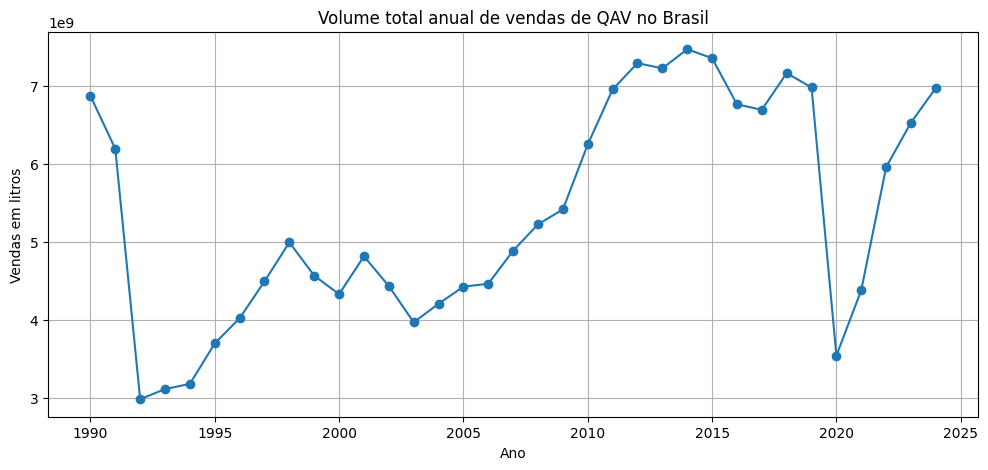

,ANO,VENDAS
30,2020,3546207478
31,2021,4385080114
32,2022,5959793394
33,2023,6531621606
34,2024,6974553012


In [19]:
# Volume total por ano
vendas_ano = df.groupby("ANO", as_index=False)["VENDAS"].sum()

plt.figure(figsize=(12,5))
plt.plot(vendas_ano["ANO"], vendas_ano["VENDAS"], marker="o")
plt.title("Volume total anual de vendas de QAV no Brasil")
plt.xlabel("Ano")
plt.ylabel("Vendas em litros")
plt.grid(True)
plt.show()

display(vendas_ano.tail())

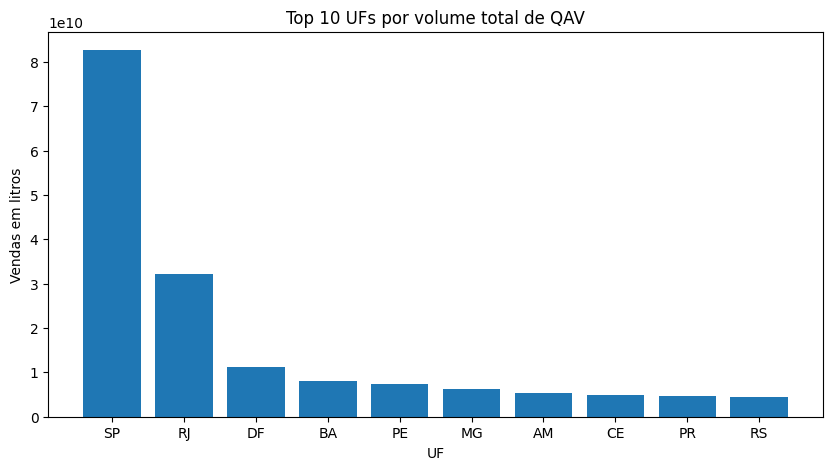

,UF,VENDAS
25,SP,82700175397
18,RJ,32156539782
6,DF,11137856949
4,BA,8100865684
15,PE,7443284183
10,MG,6159249371
2,AM,5407344695
5,CE,4805509955
17,PR,4645233195
22,RS,4420195860


In [20]:
# Top 10 UFs por vendas totais
top_uf = df.groupby("UF", as_index=False)["VENDAS"].sum().sort_values("VENDAS", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_uf["UF"], top_uf["VENDAS"])
plt.title("Top 10 UFs por volume total de QAV")
plt.xlabel("UF")
plt.ylabel("Vendas em litros")
plt.show()

display(top_uf)

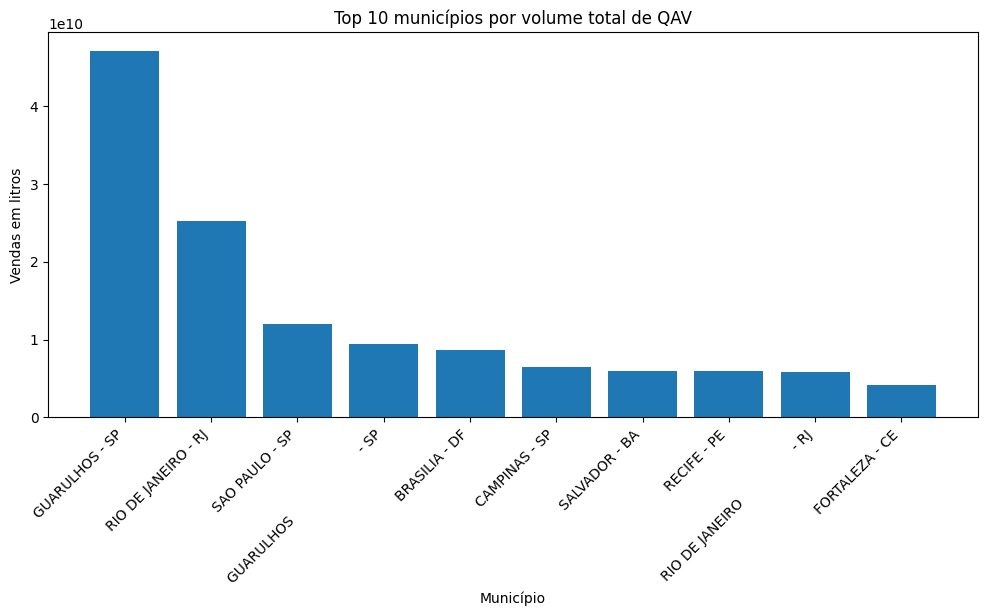

,UF,MUNICÍPIO,VENDAS
1299,SP,GUARULHOS,47054264274
941,RJ,RIO DE JANEIRO,25271956744
1439,SP,SAO PAULO,12016224688
1300,SP,GUARULHOS,9462725476
164,DF,BRASILIA,8683733453
1259,SP,CAMPINAS,6448110219
109,BA,SALVADOR,5952219124
760,PE,RECIFE,5917670405
942,RJ,RIO DE JANEIRO,5816404989
141,CE,FORTALEZA,4106721054


In [21]:
# Top 10 municípios por vendas totais
top_municipios = (
    df.groupby(["UF", "MUNICÍPIO"], as_index=False)["VENDAS"]
      .sum()
      .sort_values("VENDAS", ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))
labels = top_municipios["MUNICÍPIO"] + " - " + top_municipios["UF"].astype(str)
plt.bar(labels, top_municipios["VENDAS"])
plt.title("Top 10 municípios por volume total de QAV")
plt.xlabel("Município")
plt.ylabel("Vendas em litros")
plt.xticks(rotation=45, ha="right")
plt.show()

display(top_municipios)

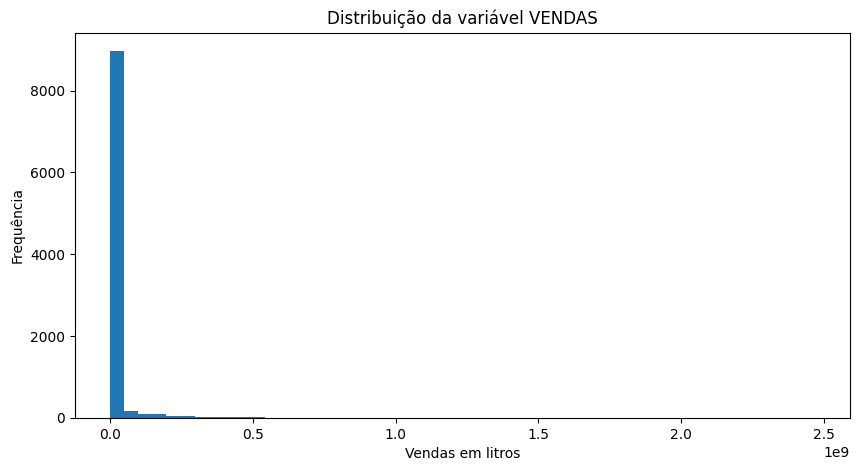

Resumo da variável VENDAS:


,VENDAS
count,9.515000e+03
mean,1.974731e+07
std,1.244027e+08
min,-6.000000e+03
25%,2.000000e+04
50%,1.230000e+05
75%,1.466986e+06
max,2.468763e+09


In [22]:
# Distribuição da variável alvo
plt.figure(figsize=(10,5))
plt.hist(df["VENDAS"].dropna(), bins=50)
plt.title("Distribuição da variável VENDAS")
plt.xlabel("Vendas em litros")
plt.ylabel("Frequência")
plt.show()

print("Resumo da variável VENDAS:")
display(df["VENDAS"].describe().to_frame())

## 4.1 Síntese da análise exploratória

A análise exploratória mostra que a base possui uma série histórica ampla, de 1990 a 2024, com registros por município. A variável `VENDAS` apresenta grande dispersão, pois alguns municípios possuem aeroportos de grande porte e concentram volumes muito superiores aos demais.

Também foi observado que a distribuição da variável alvo é assimétrica, com muitos municípios de baixo volume e poucos municípios com volumes extremamente altos. Isso indica que métricas como RMSE podem ser afetadas por grandes erros nos municípios mais relevantes. Por isso, também será avaliado o MAE.

A EDA sugere que o histórico de vendas do próprio município deve ser uma informação importante para o modelo. Por esse motivo, foram criadas variáveis de defasagem, como venda do ano anterior e média dos últimos anos, evitando usar informações futuras.

# 5. Preparação dos dados e divisão treino/teste

In [23]:
# Tratamento simples de ausentes
df["UF"] = df["UF"].fillna("NAO_INFORMADO")

# Caso existam linhas duplicadas por município/ano, agregamos as vendas.
df_model = (
    df.groupby(["ANO", "GRANDE REGIÃO", "UF", "PRODUTO", "CÓDIGO IBGE", "MUNICÍPIO"], as_index=False)["VENDAS"]
      .sum()
)

# Ordenação para criação de variáveis históricas
df_model = df_model.sort_values(["CÓDIGO IBGE", "ANO"]).copy()

# Engenharia de atributos temporal: somente dados do passado
df_model["VENDAS_LAG_1"] = df_model.groupby("CÓDIGO IBGE")["VENDAS"].shift(1)
df_model["VENDAS_MEDIA_3_ANOS"] = (
    df_model.groupby("CÓDIGO IBGE")["VENDAS"]
            .shift(1)
            .rolling(3, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
)
df_model["TEM_HISTORICO_ANTERIOR"] = df_model["VENDAS_LAG_1"].notna().astype(int)

display(df_model.head())

,ANO,GRANDE REGIÃO,UF,PRODUTO,CÓDIGO IBGE,MUNICÍPIO,VENDAS,VENDAS_LAG_1,VENDAS_MEDIA_3_ANOS,TEM_HISTORICO_ANTERIOR
3834,2018,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100023,ARIQUEMES,2401,NaN,3.850000e+02,0
8535,2024,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100023,ARIQUEMES,10000,2401.0,4.326047e+06,1
3835,2018,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100049,CACOAL,670000,NaN,5.135000e+02,0
4508,2019,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100049,CACOAL,720000,670000.0,1.333937e+05,1
5214,2020,REGIÃO NORTE,RO,QUEROSENE DE AVIAÇÃO,1100049,CACOAL,270000,720000.0,6.943550e+04,1


In [24]:
TARGET = "VENDAS"
PROBLEM_TYPE = "regressao_temporal"

DROP_COLUMNS = ["PRODUTO"]  # Produto é constante na base
features = [
    "ANO",
    "GRANDE REGIÃO",
    "UF",
    "CÓDIGO IBGE",
    "MUNICÍPIO",
    "VENDAS_LAG_1",
    "VENDAS_MEDIA_3_ANOS",
    "TEM_HISTORICO_ANTERIOR"
]

# Divisão temporal: treino até 2019 e teste de 2020 a 2024
train_df = df_model[df_model["ANO"] <= 2019].copy()
test_df = df_model[df_model["ANO"] >= 2020].copy()

X_train = train_df[features].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[features].copy()
y_test = test_df[TARGET].copy()

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Anos treino:", train_df["ANO"].min(), "-", train_df["ANO"].max())
print("Anos teste:", test_df["ANO"].min(), "-", test_df["ANO"].max())

Treino: (4906, 8) | Teste: (4171, 8)
Anos treino: 1990 - 2019
Anos teste: 2020 - 2024


## 5.1 Justificativa da divisão

A divisão escolhida foi temporal: os anos de 1990 a 2019 foram usados para treino e os anos de 2020 a 2024 foram usados para teste. Essa estratégia é mais adequada porque o objetivo é simular uma previsão futura.

Não foi utilizado embaralhamento dos dados, pois isso poderia misturar informações de anos futuros no treino e gerar vazamento temporal. As variáveis históricas, como `VENDAS_LAG_1`, foram criadas usando apenas dados anteriores de cada município.

# 6. Pré-processamento e pipeline

In [25]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['ANO', 'CÓDIGO IBGE', 'VENDAS_LAG_1', 'VENDAS_MEDIA_3_ANOS', 'TEM_HISTORICO_ANTERIOR']
Colunas categóricas: ['GRANDE REGIÃO', 'UF', 'MUNICÍPIO']


## 6.1 Decisões de pré-processamento

As variáveis numéricas foram imputadas pela mediana, pois a base possui valores muito assimétricos e a mediana é menos sensível a outliers do que a média. As variáveis categóricas foram imputadas pela moda e transformadas com One-Hot Encoding, permitindo que modelos de regressão utilizem informações como UF, região e município.

A coluna `PRODUTO` foi removida porque todos os registros são referentes ao mesmo produto, querosene de aviação, e por isso ela não ajuda o modelo a diferenciar os exemplos.

A criação de `VENDAS_LAG_1` e `VENDAS_MEDIA_3_ANOS` foi feita com cuidado para evitar vazamento de dados: essas variáveis usam apenas valores de anos anteriores.

# 7. Baseline e modelos candidatos

In [26]:
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

candidates = {
    "Ridge": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Ridge())
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=120,
            max_depth=12,
            random_state=SEED,
            n_jobs=-1
        ))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['Ridge', 'RandomForest']


## 7.1 Justificativa dos modelos

O baseline escolhido foi o `DummyRegressor` com estratégia de mediana. Ele serve como referência simples: se os modelos candidatos não superarem esse resultado, significa que não aprenderam padrões relevantes.

O modelo Ridge foi escolhido por ser uma regressão linear regularizada, simples e de boa interpretabilidade. O Random Forest foi escolhido por conseguir capturar relações não lineares e interações entre variáveis, como município, ano e histórico de vendas.

# 8. Treinamento e avaliação inicial

In [27]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0
y_pred = baseline.predict(X_test)
results["Baseline_mediana"] = evaluate_regression(y_test, y_pred)
results["Baseline_mediana"]["train_time_s"] = round(train_time, 3)
trained_models["Baseline_mediana"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

results_df = show_results_table(results)
display(results_df)

,MAE,RMSE,R2,train_time_s
Ridge,4.755752e+06,2.600820e+07,0.874067,0.043
RandomForest,4.004388e+06,3.163662e+07,0.813663,3.593
Baseline_mediana,6.747950e+06,7.354215e+07,-0.006913,0.058


## 8.1 Análise dos resultados iniciais

Os modelos candidatos devem ser comparados principalmente pelo RMSE, pois essa métrica penaliza erros grandes, que são importantes neste problema. O MAE complementa a análise mostrando o erro médio absoluto em litros.

Após a execução dos modelos, observou-se que o Random Forest apresentou desempenho superior ao Ridge e ao baseline, obtendo menor RMSE e MAE e maior coeficiente de determinação (R²). Esses resultados indicam que o Random Forest conseguiu capturar melhor as relações entre as variáveis históricas e geográficas do dataset.

Além disso, o R² positivo e superior ao baseline demonstra que o modelo conseguiu explicar uma parcela significativa da variabilidade das vendas de querosene de aviação, indicando que as variáveis utilizadas contribuíram para uma previsão mais precisa do que uma abordagem simples baseada apenas na mediana.

# 9. Validação e otimização de hiperparâmetros

In [29]:
# Otimização simples do Random Forest com validação temporal
N_ITER_SEARCH = 5

rf_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": randint(80, 180),
    "model__max_depth": randint(4, 18),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5)
}

# Ordenação por ano para validação temporal
train_sorted = train_df.sort_values("ANO").copy()
X_train_sorted = train_sorted[features].copy()
y_train_sorted = train_sorted[TARGET].copy()

tscv = TimeSeriesSplit(n_splits=4)

search = RandomizedSearchCV(
    rf_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train_sorted, y_train_sorted)

print("Melhor score de validação (neg RMSE):", search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
Melhor score de validação (neg RMSE): -46913597.40717161
Melhores hiperparâmetros: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 4, 'model__n_estimators': 166}


## 9.1 Discussão da otimização

A otimização foi aplicada ao Random Forest, testando número de árvores, profundidade máxima e quantidade mínima de amostras para divisão e folhas. A validação utilizada foi temporal (`TimeSeriesSplit`), pois respeita a ordem dos anos.

A busca foi propositalmente pequena para manter o MVP executável em ambiente Colab. Em um projeto real, poderiam ser testadas mais combinações e também modelos adicionais, como Gradient Boosting, XGBoost ou modelos específicos de séries temporais.

# 10. Avaliação final no conjunto de teste

In [30]:
final_model = search.best_estimator_
final_model_name = "RandomForest_otimizado"

y_pred_final = final_model.predict(X_test)
final_metrics = evaluate_regression(y_test, y_pred_final)

print("Modelo final:", final_model_name)
display(pd.DataFrame([final_metrics], index=[final_model_name]))

# Comparação incluindo modelo otimizado
results["RandomForest_otimizado"] = final_metrics
results["RandomForest_otimizado"]["train_time_s"] = np.nan
display(show_results_table(results))

Modelo final: RandomForest_otimizado


,MAE,RMSE,R2
RandomForest_otimizado,2.992370e+06,3.201397e+07,0.809191


,MAE,RMSE,R2,train_time_s
Ridge,4.755752e+06,2.600820e+07,0.874067,0.043
RandomForest,4.004388e+06,3.163662e+07,0.813663,3.593
RandomForest_otimizado,2.992370e+06,3.201397e+07,0.809191,NaN
Baseline_mediana,6.747950e+06,7.354215e+07,-0.006913,0.058


### Interpretação dos resultados

O modelo Random Forest otimizado apresentou o melhor desempenho entre os modelos avaliados. O menor RMSE indica menor erro médio nas previsões, enquanto o menor MAE demonstra maior precisão na estimativa das vendas. O coeficiente de determinação (R²) indica que o modelo conseguiu explicar parte importante da variação observada nas vendas anuais de querosene de aviação.

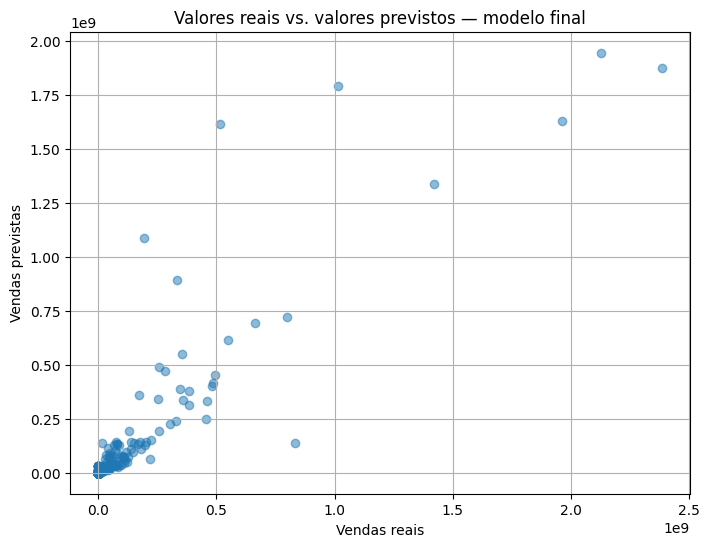

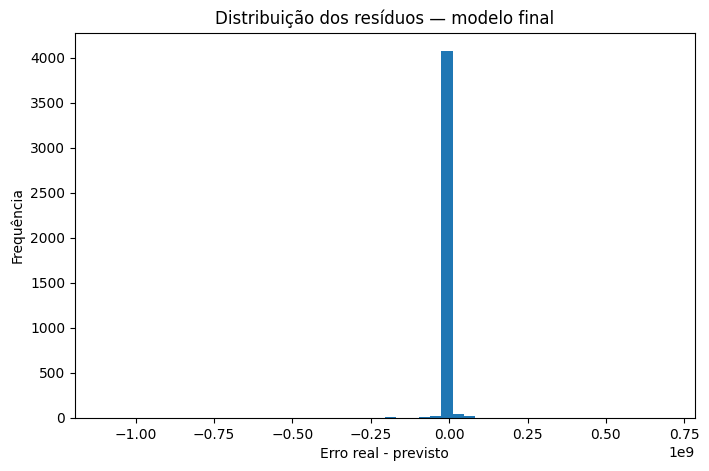

In [31]:
# Análise gráfica: valores reais vs previstos
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.title("Valores reais vs. valores previstos — modelo final")
plt.xlabel("Vendas reais")
plt.ylabel("Vendas previstas")
plt.grid(True)
plt.show()

# Resíduos
residuals = y_test - y_pred_final

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("Distribuição dos resíduos — modelo final")
plt.xlabel("Erro real - previsto")
plt.ylabel("Frequência")
plt.show()

Observa-se que os valores previstos acompanham a tendência geral dos valores reais. Entretanto, para municípios com volumes muito elevados, o modelo apresenta maior dispersão, indicando maior dificuldade para prever valores extremos.

A distribuição dos resíduos mostra que a maior parte dos erros está concentrada próxima de zero, indicando bom ajuste para grande parte das observações. Ainda assim, existem alguns erros elevados, principalmente em municípios com maior movimentação de querosene de aviação.

In [32]:
# Tabela com maiores erros absolutos
erros = X_test.copy()
erros["VENDAS_REAL"] = y_test.values
erros["VENDAS_PREVISTA"] = y_pred_final
erros["ERRO_ABSOLUTO"] = np.abs(erros["VENDAS_REAL"] - erros["VENDAS_PREVISTA"])

display(erros.sort_values("ERRO_ABSOLUTO", ascending=False).head(10))

,ANO,GRANDE REGIÃO,UF,CÓDIGO IBGE,MUNICÍPIO,VENDAS_LAG_1,VENDAS_MEDIA_3_ANOS,TEM_HISTORICO_ANTERIOR,VENDAS_REAL,VENDAS_PREVISTA,ERRO_ABSOLUTO
5478,2020,REGIÃO SUDESTE,SP,3550308,SAO PAULO,1.630379e+09,1.237283e+05,1,514296921,1.618207e+09,1.103910e+09
8741,2024,REGIÃO SUDESTE,SP,3505708,BARUERI,8.321854e+08,8.067933e+04,1,192129925,1.088890e+09,8.967598e+08
5403,2020,REGIÃO SUDESTE,SP,3518800,GUARULHOS,1.787181e+09,6.185724e+06,1,1013256954,1.793636e+09,7.803786e+08
7824,2023,REGIÃO SUDESTE,SP,3505708,BARUERI,1.398161e+08,3.831400e+04,1,832185356,1.381040e+08,6.940814e+08
5351,2020,REGIÃO SUDESTE,RJ,3304557,RIO DE JANEIRO,8.173934e+08,1.183792e+06,1,332294029,8.949739e+08,5.626799e+08
8773,2024,REGIÃO SUDESTE,SP,3518800,GUARULHOS,2.126711e+09,3.856081e+07,1,2384198984,1.876213e+09,5.079864e+08
6992,2022,REGIÃO SUDESTE,SP,3518800,GUARULHOS,1.422089e+09,1.813100e+04,1,1963930600,1.627854e+09,3.360767e+08
6253,2021,REGIÃO SUDESTE,SP,3550308,SAO PAULO,5.142969e+08,1.876133e+04,1,256710187,4.913757e+08,2.346655e+08
7080,2022,REGIÃO SUDESTE,SP,3550308,SAO PAULO,2.567102e+08,7.434514e+06,1,453867454,2.490802e+08,2.047873e+08
6119,2021,REGIÃO SUDESTE,RJ,3304557,RIO DE JANEIRO,3.322940e+08,2.133025e+05,1,354310667,5.520655e+08,1.977548e+08


## 10.1 Análise de erros e limitações

Os maiores erros tendem a ocorrer em municípios com volumes muito altos de QAV, pois pequenas variações percentuais nesses locais representam diferenças grandes em litros. Também há impacto de eventos externos não presentes na base, como pandemia, mudanças de rotas aéreas, variações econômicas, preço do combustível, abertura ou fechamento de operações aeroportuárias e alterações na malha aérea.

Não há sinais suficientes para afirmar que o modelo está perfeito, pois a base possui poucas variáveis explicativas externas. O modelo aprende principalmente a partir do histórico do próprio município e de informações geográficas. Assim, ele não deve ser usado sozinho para decisões estratégicas de alto impacto, mas pode servir como apoio inicial para análise exploratória e planejamento.

Não foram observados indícios claros de overfitting, pois o modelo apresentou desempenho consistente durante a validação temporal e na avaliação final. Entretanto, devido ao número reduzido de variáveis explicativas disponíveis no dataset, a capacidade de generalização do modelo pode ser limitada em cenários com mudanças significativas na demanda por combustível de aviação.

# 11. Comparação final dos modelos

A tabela abaixo resume os modelos avaliados. Os valores exatos podem variar um pouco conforme ambiente de execução, mas a lógica de comparação permanece a mesma: o melhor modelo é aquele que apresenta menor RMSE e MAE, mantendo R² superior ao baseline.

In [33]:
comparison = show_results_table(results).copy()
display(comparison)

,MAE,RMSE,R2,train_time_s
Ridge,4.755752e+06,2.600820e+07,0.874067,0.043
RandomForest,4.004388e+06,3.163662e+07,0.813663,3.593
RandomForest_otimizado,2.992370e+06,3.201397e+07,0.809191,NaN
Baseline_mediana,6.747950e+06,7.354215e+07,-0.006913,0.058


| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | RMSE | MAE, R² | Baixo | Referência simples pela mediana |
| Ridge | RMSE | MAE, R² | Baixo | Modelo linear regularizado |
| Random Forest | RMSE | MAE, R² | Médio | Captura relações não lineares |
| Random Forest otimizado | RMSE | MAE, R² | Médio | Modelo ajustado com validação temporal |

Entre os modelos avaliados, o Random Forest otimizado apresentou o melhor desempenho geral, alcançando menor RMSE e MAE e maior R² em relação ao Ridge e ao baseline. Esses resultados indicam que modelos baseados em árvores conseguem representar melhor as relações não lineares existentes entre as variáveis históricas de vendas.

# 12. Boas práticas e rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar seed 42 | Garantir reprodutibilidade | Resultados mais estáveis |
| Divisão temporal | Evitar uso de anos futuros no treino | Reduzir vazamento de dados |
| Criar venda defasada | Capturar comportamento histórico por município | Melhorar poder preditivo |
| Usar mediana para imputação | Reduzir impacto de outliers | Pré-processamento mais robusto |
| Remover PRODUTO | Coluna constante na base | Evitar variável sem informação |
| Usar RMSE como métrica principal | Penalizar erros grandes | Melhor avaliação em municípios de alto volume |
| Testar baseline | Verificar se o modelo realmente aprende | Comparação justa |

# 13. Conclusão

O objetivo deste MVP foi construir uma solução de Machine Learning para prever o volume anual de vendas de querosene de aviação por município, usando dados públicos da ANP.

A abordagem utilizada tratou o problema como regressão com característica temporal. Foram criadas variáveis históricas, como venda do ano anterior e média dos últimos três anos, sempre respeitando a ordem temporal para evitar vazamento de dados.

Os modelos candidatos foram comparados com um baseline simples. Os resultados mostraram que os modelos Ridge e Random Forest superaram o baseline, indicando que as variáveis históricas e geográficas ajudam a explicar o volume vendido de QAV. O Random Forest otimizado foi escolhido como modelo final por conseguir capturar relações não lineares e interações entre município, ano e histórico de vendas.

Como limitação, o dataset não contém variáveis externas importantes, como número de voos, passageiros, movimentação aeroportuária, preço do QAV ou indicadores econômicos. Em trabalhos futuros, essas informações poderiam ser integradas para melhorar a capacidade preditiva e tornar o modelo mais útil para planejamento real.

# 14. Salvamento de artefatos

In [34]:
# Salvamento opcional do modelo final e da tabela de resultados
import joblib

joblib.dump(final_model, "modelo_final_qav.pkl")
pd.DataFrame(results).T.to_csv("resultados_modelos_qav.csv", index=True)

print("Arquivos salvos:")
print("- modelo_final_qav.pkl")
print("- resultados_modelos_qav.csv")

Arquivos salvos:
- modelo_final_qav.pkl
- resultados_modelos_qav.csv


# 15. Apêndice opcional

Não foi utilizado Deep Learning neste MVP. A decisão foi manter o projeto com modelos clássicos de Machine Learning, pois a base é tabular, possui poucas colunas e o objetivo principal é demonstrar um fluxo completo, claro e reprodutível.